# AIloQR - Machine Learning Research & Analysis

This notebook details the synthetic data generation, training experiments, and evaluation metrics for the Isolation Forest anomaly detection model implemented in the AIloQR application.

---

**INITIAL CONFIGURATION**

In [1]:
# ==============================================================================
# SETUP & INITIALIZATION
# ==============================================================================

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    f1_score, recall_score, roc_curve, auc
)

# Fix random seeds for reproducibility of the experiments
random.seed(42)
np.random.seed(42)

# --- GLOBAL EXPERIMENT CONFIGURATION ---
N_SAMPLES = 10000
START_DATE = datetime(2026, 1, 1, 0, 0, 0)
FEATURE_COLUMNS = [
    'role_encoded', 'area_encoded', 'hour', 'weekday',
    'is_admin', 'time_since_last_access', 'access_frequency_1h'
]

# Initialize global AI pipeline components
label_encoders = {}
scaler = StandardScaler()
model = IsolationForest(contamination='auto', random_state=42)

# Define Role-Based Access Control (RBAC) baseline profiles
# Includes allowed areas, standard operational hours, and data generation weights
ROLES_CONFIG = {
    'Student': {'areas': ['Classroom_1', 'Library', 'Gym'], 'hours': (7, 23), 'weight': 0.75},
    'Staff': {'areas': ['Classroom_1', 'Library', 'Office_Block'], 'hours': (7, 23), 'weight': 0.10},
    'Professor': {'areas': ['Classroom_1', 'Office_Block', 'Lab'], 'hours': (7, 23), 'weight': 0.12},
    'Admin': {'areas': ['Classroom_1', 'Library', 'Gym', 'Office_Block', 'Lab', 'Server_Room'], 'hours': (0, 24), 'weight': 0.03}
}

# Dynamically extract all available areas from the configuration
AREAS_TOTALS = list(set(area for config in ROLES_CONFIG.values() for area in config['areas']))

**DATA GENERATION**



In [2]:
# ==============================================================================
# SYNTHETIC DATA GENERATION
# ==============================================================================

def generate_data(mode='test'):
    """
    Generates synthetic access logs simulating realistic human behavior patterns.
    Injects anomalies and rule violations during the 'test' mode to evaluate
    the Isolation Forest model's detection capabilities.
    """
    data = []
    roles = list(ROLES_CONFIG.keys())
    role_weights = [ROLES_CONFIG[r]['weight'] for r in roles]

    # Model probability distribution by day of the week (higher volume on weekdays)
    dates_pool = [START_DATE + timedelta(days=i) for i in range(30)]
    date_weights = []
    for d in dates_pool:
        if d.weekday() < 4:
            date_weights.append(1.0)  # Monday - Thursday: Maximum access volume
        elif d.weekday() == 4:
            date_weights.append(0.7)  # Friday: Moderate access volume
        else:
            date_weights.append(0.1)  # Weekend: Residual/Low accesses

    # Normalize temporal weights
    date_weights = [w / sum(date_weights) for w in date_weights]

    for _ in range(N_SAMPLES):
        # Define the ground truth nature of the access attempt
        case_type = 'normal' if mode == 'train' else np.random.choice(['normal', 'blocked', 'anomaly'], p=[0.85, 0.07, 0.08])

        role = np.random.choice(roles, p=role_weights)
        config = ROLES_CONFIG[role]

        access_date = np.random.choice(dates_pool, p=date_weights)
        is_weekday = access_date.weekday() < 5

        start_h, end_h = config['hours']
        reason = "Valid access"

        # --- NORMATIVE BEHAVIOR GENERATION ---
        if case_type == 'normal':
            area = random.choice(config['areas'])
            allowed = True

            # Student behavioral patterns (Transit during class changes)
            if role == 'Student' and is_weekday:
                if random.random() < 0.70:
                    valid_class_hours = [h for h in [8, 10, 12, 14, 16, 18, 20] if start_h <= h < end_h]
                    hour = random.choice(valid_class_hours) if valid_class_hours else random.choice(range(start_h, end_h))
                    minute = max(0, min(59, int(np.random.normal(loc=30, scale=10))))
                else:
                    hour = random.choice(range(start_h, end_h))
                    minute = random.randint(0, 59)

            # Professor behavioral patterns (Early arrivals & class changes)
            elif role == 'Professor' and is_weekday:
                rand_val = random.random()
                if rand_val < 0.25:
                    hour = random.choice([7, 21])
                    loc_min = 50 if hour == 7 else 10
                    minute = max(0, min(59, int(np.random.normal(loc=loc_min, scale=8))))
                elif rand_val < 0.70:
                    valid_class_hours = [h for h in [8, 10, 12, 14, 16, 18, 20] if start_h <= h < end_h]
                    hour = random.choice(valid_class_hours) if valid_class_hours else random.choice(range(start_h, end_h))
                    minute = max(0, min(59, int(np.random.normal(loc=30, scale=10))))
                else:
                    hour = random.choice(range(start_h, end_h))
                    minute = random.randint(0, 59)

            # Staff & Admin behavioral patterns (Standard operational shifts)
            elif role in ['Staff', 'Admin'] and is_weekday:
                if random.random() < 0.40:
                    hour = random.choice([start_h, end_h - 1])
                    minute = max(0, min(59, int(np.random.normal(loc=30, scale=15))))
                else:
                    hour = random.choice(range(start_h, end_h))
                    minute = random.randint(0, 59)
            else:
                # Weekends or unmatched periods
                hour = random.choice(range(start_h, end_h))
                minute = random.randint(0, 59)

        # --- HARD RULE VIOLATION (BLOCKED) ---
        elif case_type == 'blocked':
            forbidden = [a for a in AREAS_TOTALS if a not in config['areas']]
            area = random.choice(forbidden) if forbidden else 'Server_Room'
            hour = random.randint(9, 17)
            minute = random.randint(0, 59)
            allowed = False
            reason = "AREA_VIOLATION"

        # --- AI ANOMALY (UNUSUAL BEHAVIOR) ---
        else:
            area = random.choice(config['areas'])
            # Select hours outside the standard normative bounds
            hour = random.choice([23, 0, 1, 2, 3, 4, 5, 6])
            minute = random.randint(0, 59)
            allowed = start_h <= hour < end_h
            reason = "Valid access" if allowed else "TIME_VIOLATION"

        access_time = access_date.replace(hour=hour, minute=minute, second=random.randint(0, 59))
        data.append([f"{role.lower()}_{random.randint(1, 30)}", role, area, access_time, allowed, reason, case_type])

    # Compile to DataFrame and calculate rolling temporal features
    df = pd.DataFrame(data, columns=['user_id', 'role', 'area', 'access_time', 'allowed', 'reason', 'ground_truth'])
    df = df.sort_values(['user_id', 'access_time'])

    # Feature Engineering: Time deltas and frequency clustering
    df['time_since_last_access'] = df.groupby('user_id')['access_time'].diff().dt.total_seconds().fillna(3600)
    df = df.set_index('access_time')
    df['access_frequency_1h'] = df.groupby('user_id')['user_id'].rolling('1h').count().values

    return df.reset_index()

**AI MODEL DEFINITION**

In [3]:
# ==============================================================================
# CELL 3: AI MODEL & PREPROCESSING DEFINITIONS
# ==============================================================================

def preprocess_data(df, is_training=False):
    """
    Applies Feature Engineering and scaling to the dataset.
    Extracts temporal variables and encodes categorical features safely.
    """
    global label_encoders, scaler
    df['hour'] = df['access_time'].dt.hour
    df['weekday'] = df['access_time'].dt.dayofweek
    df['is_admin'] = df['role'].apply(lambda x: 1 if x == 'Admin' else 0)

    # Label Encoding for spatial and hierarchical data
    for col in ['role', 'area']:
        encoder = label_encoders.get(col, LabelEncoder())
        if is_training:
            df[f'{col}_encoded'] = encoder.fit_transform(df[col])
            label_encoders[col] = encoder
        else:
            # Handle previously unseen labels gracefully during inference
            df[f'{col}_encoded'] = df[col].apply(
                lambda x: encoder.transform([x])[0] if x in encoder.classes_ else len(encoder.classes_)
            )

    # Standardize continuous variables (Z-score normalization)
    cols_to_scale = ['hour', 'weekday', 'time_since_last_access', 'access_frequency_1h']
    if is_training:
        scaler = StandardScaler()
        df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    else:
        df[cols_to_scale] = scaler.transform(df[cols_to_scale])

    return df

def train_model(train_df):
    """
    Initializes and trains the Unsupervised Isolation Forest model
    using exclusively normative historical data.
    """
    global model
    df_processed = preprocess_data(train_df, is_training=True)
    model = IsolationForest(contamination='auto', random_state=42)
    model.fit(df_processed[FEATURE_COLUMNS])

def get_anomaly_score(log_entry, features):
    """
    Computes the raw path-length anomaly score for a single access attempt.
    """
    log_df = pd.DataFrame([log_entry])
    log_df['time_since_last_access'] = features['time_since_last_access']
    log_df['access_frequency_1h'] = features['access_frequency_1h']

    log_processed = preprocess_data(log_df, is_training=False)
    return model.decision_function(log_processed[FEATURE_COLUMNS])[0]

**EVALUATION METRICS**

In [4]:
# ==============================================================================
# EVALUATION METRICS & VISUALIZATION TOOLS
# ==============================================================================

def plot_advanced_metrics(df, scores, y_true):
    """
    Generates and exports advanced evaluation charts including ROC curves,
    score distribution histograms, and Trade-off analyses.
    """
    # 1. Receiver Operating Characteristic (ROC) Curve
    plt.figure(figsize=(8, 6))
    fpr, tpr, _ = roc_curve(y_true, -scores)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig('roc_curve_final.pdf', bbox_inches='tight')
    plt.savefig('roc_curve_final.png', bbox_inches='tight', dpi=300)
    plt.close()

    # 2. Anomaly Score Distribution (Normal vs Anomalous)
    plt.figure(figsize=(10, 6))
    sns.histplot(scores[~y_true], color="skyblue", label="Normal", kde=True, stat="density", alpha=0.5)
    sns.histplot(scores[y_true], color="red", label="Anomalous", kde=True, stat="density", alpha=0.5)
    plt.axvline(x=-0.025, color='black', linestyle='--', label='Operational Threshold (-0.025)')
    plt.title('Anomaly Score Distribution: Normal vs. Threat Profiles', fontsize=14)
    plt.xlabel('Isolation Forest Score (Path Length Indicator)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.2)
    plt.savefig('anomaly_distribution_final.pdf', bbox_inches='tight')
    plt.savefig('anomaly_distribution_final.png', bbox_inches='tight', dpi=300)
    plt.close()

    # 3. Comprehensive Dashboard
    plt.figure(figsize=(18, 10))

    plt.subplot(2, 2, 1)
    plt.plot(df['Threshold'], df['Recall'], 'r-o', label='Security (Recall)')
    plt.plot(df['Threshold'], df['Precision'], 'g-s', label='Usability (Precision)')
    plt.plot(df['Threshold'], df['F1-Score'], 'b--', label='F1 (Balance)')
    plt.title('Security vs Usability Trade-off')
    plt.xlabel('Anomaly Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    sns.histplot(scores[~y_true], color="skyblue", label="Normal", kde=True, stat="density", alpha=0.5)
    sns.histplot(scores[y_true], color="red", label="Anomalous", kde=True, stat="density", alpha=0.5)
    plt.axvline(x=-0.025, color='black', linestyle='--', label='Threshold (-0.025)')
    plt.title('Anomaly Score Distribution')
    plt.xlabel('Isolation Forest Score')
    plt.legend()
    plt.grid(True, alpha=0.2)

    plt.subplot(2, 2, 4)
    plt.plot(df['Threshold'], df['Intruder Det.'], marker='o', label='Intruder Detection')
    plt.plot(df['Threshold'], df['Blocked Det.'], marker='x', label='Rule Violation Detection')
    plt.title('Detection Success by Threat Type')
    plt.xlabel('Threshold')
    plt.ylabel('Detection Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_severity_analysis(df, scores, threshold=-0.05):
    """
    Evaluates and plots the AI Severity classification (LOW, MEDIUM, CRITICAL)
    based on dynamic distance from the operational threshold.
    """
    distances = threshold - scores
    severities = []

    # Map numerical scores to operational severity labels
    for d, s in zip(distances, scores):
        if s >= threshold:
            severities.append('Normal (No Alert)')
        elif d >= 0.10:
            severities.append('CRITICAL')
        elif d >= 0.04:
            severities.append('MEDIUM')
        else:
            severities.append('LOW')

    df['ai_severity'] = severities
    df['anomaly_score'] = scores

    plt.figure(figsize=(16, 6))

    # Boxplot of scores by Ground Truth
    plt.subplot(1, 2, 1)
    sns.boxplot(x='ground_truth', y='anomaly_score', data=df, palette='muted')
    plt.axhline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.3f})')
    plt.axhline(threshold - 0.04, color='orange', linestyle=':', label=f'Medium Bound ({threshold - 0.04:.3f})')
    plt.axhline(threshold - 0.10, color='red', linestyle=':', label=f'Critical Bound ({threshold - 0.10:.3f})')

    plt.axhspan(threshold, max(scores) + 0.05, color='green', alpha=0.1, label='Allowed Zone')
    plt.axhspan(threshold - 0.04, threshold, color='yellow', alpha=0.2, label='LOW Severity')
    plt.axhspan(threshold - 0.10, threshold - 0.04, color='orange', alpha=0.2, label='MEDIUM Severity')
    plt.axhspan(min(scores) - 0.05, threshold - 0.10, color='red', alpha=0.15, label='CRITICAL Severity')

    plt.title(f'Access Severity Breakdown (Threshold = {threshold})', fontsize=14)
    plt.xlabel('True Access Type (Ground Truth)')
    plt.ylabel('Isolation Forest Score')
    plt.legend(loc='upper right', fontsize=9)

    # Stacked bar chart of Severity Classifications
    plt.subplot(1, 2, 2)
    crosstab = pd.crosstab(df['ground_truth'], df['ai_severity'], normalize='index') * 100
    cols_order = [c for c in ['Normal (No Alert)', 'LOW', 'MEDIUM', 'CRITICAL'] if c in crosstab.columns]
    crosstab = crosstab[cols_order]
    colors = {'Normal (No Alert)': 'lightgreen', 'LOW': '#ffd700', 'MEDIUM': 'darkorange', 'CRITICAL': 'darkred'}
    plot_colors = [colors[c] for c in cols_order]

    crosstab.plot(kind='bar', stacked=True, color=plot_colors, ax=plt.gca(), edgecolor='black')
    plt.title('AI Classification by Access Type', fontsize=14)
    plt.xlabel('True Access Type (Ground Truth)')
    plt.ylabel('Percentage (%)')
    plt.legend(title='AI Verdict', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig(f'severity_breakdown_th_{threshold}.pdf', bbox_inches='tight')
    plt.savefig(f'severity_breakdown_th_{threshold}.png', bbox_inches='tight', dpi=300)
    plt.show()

**EXPERIMENT EXECUTION**

[1/4] Preparing realistic synthetic datasets (Train & Test)...
[2/4] Training Unsupervised Isolation Forest model...
[3/4] Running inference and calculating anomaly scores...
[4/4] Generating evaluation metrics...

--- PERFORMANCE SUMMARY TABLE (Isolation Forest Classification) ---
 Threshold  Accuracy  Precision   Recall  F1-Score  False Positives  Intruder Det.  Blocked Det.
    -0.150    0.8274   0.125413 0.025350  0.042175              265       0.025608      0.025070
    -0.100    0.8142   0.169429 0.061374  0.090108              451       0.074264      0.047354
    -0.050    0.7821   0.188645 0.137425  0.159012              886       0.137004      0.137883
    -0.025    0.7438   0.201907 0.240160  0.219378             1423       0.245839      0.233983
    -0.020    0.7318   0.201715 0.266845  0.229753             1583       0.270166      0.263231
    -0.010    0.7062   0.198576 0.316211  0.243953             1913       0.306018      0.327298
     0.000    0.6832   0.204602 0.3855

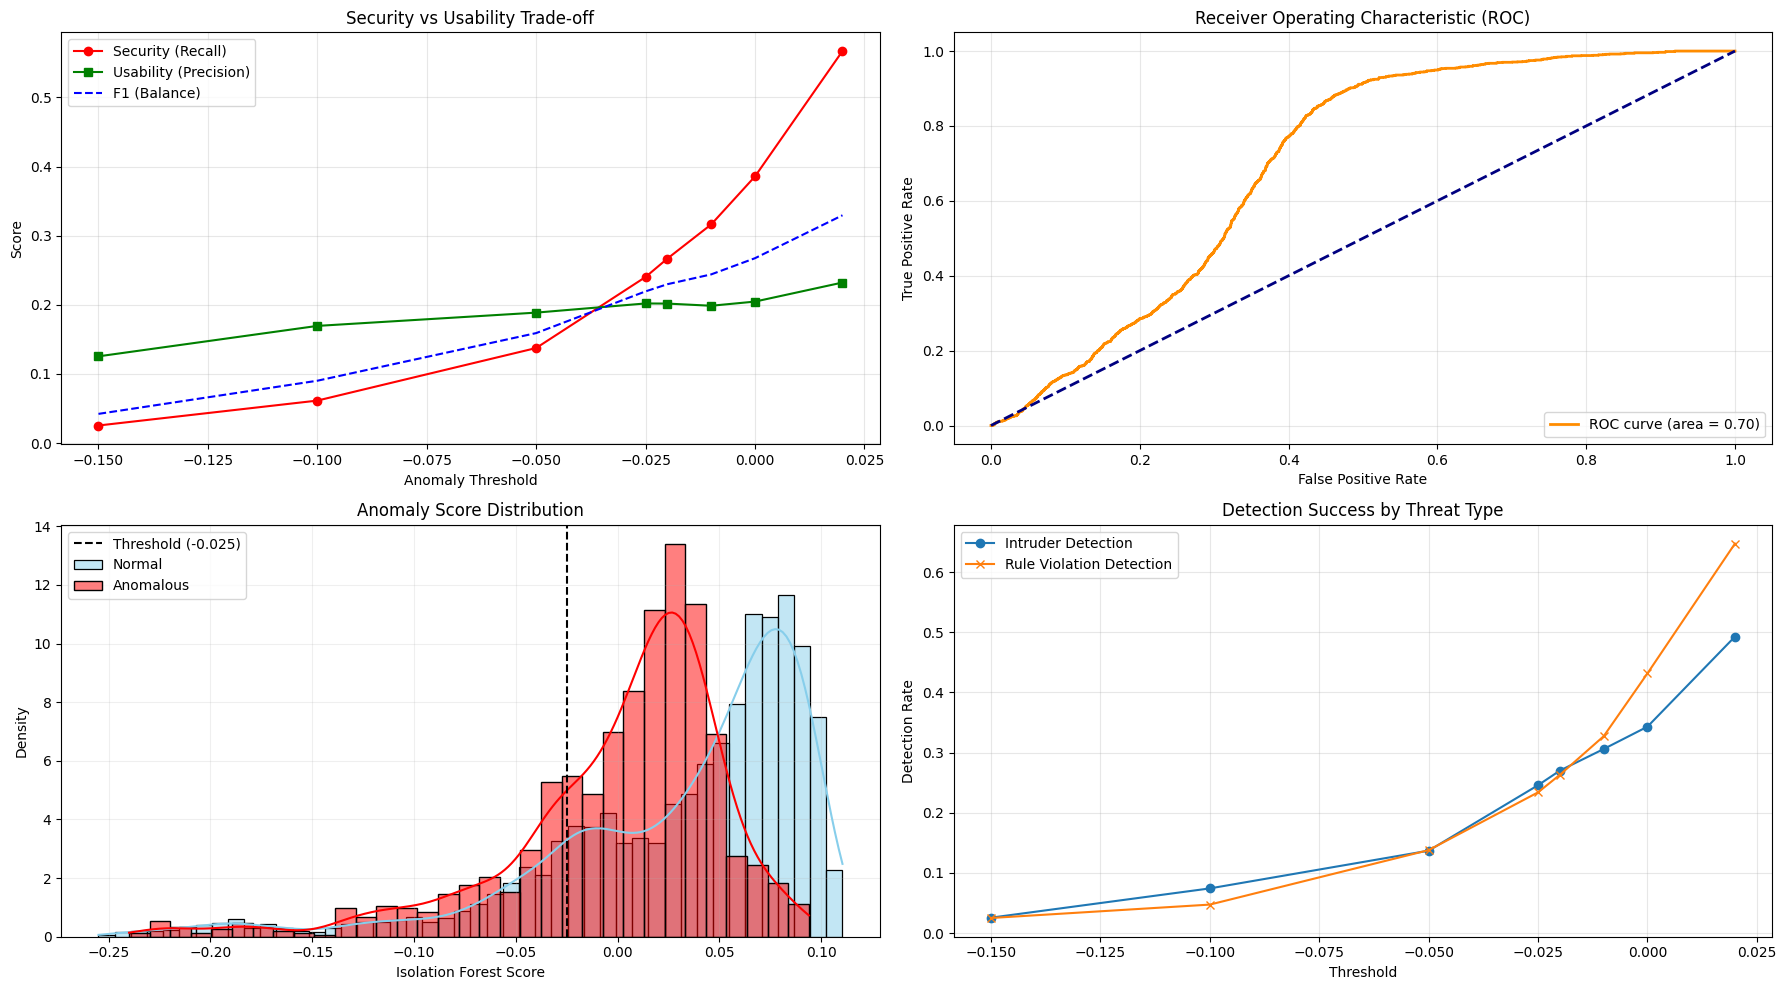

/tmp/ipykernel_1753/3218878555.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ground_truth', y='anomaly_score', data=df, palette='muted')


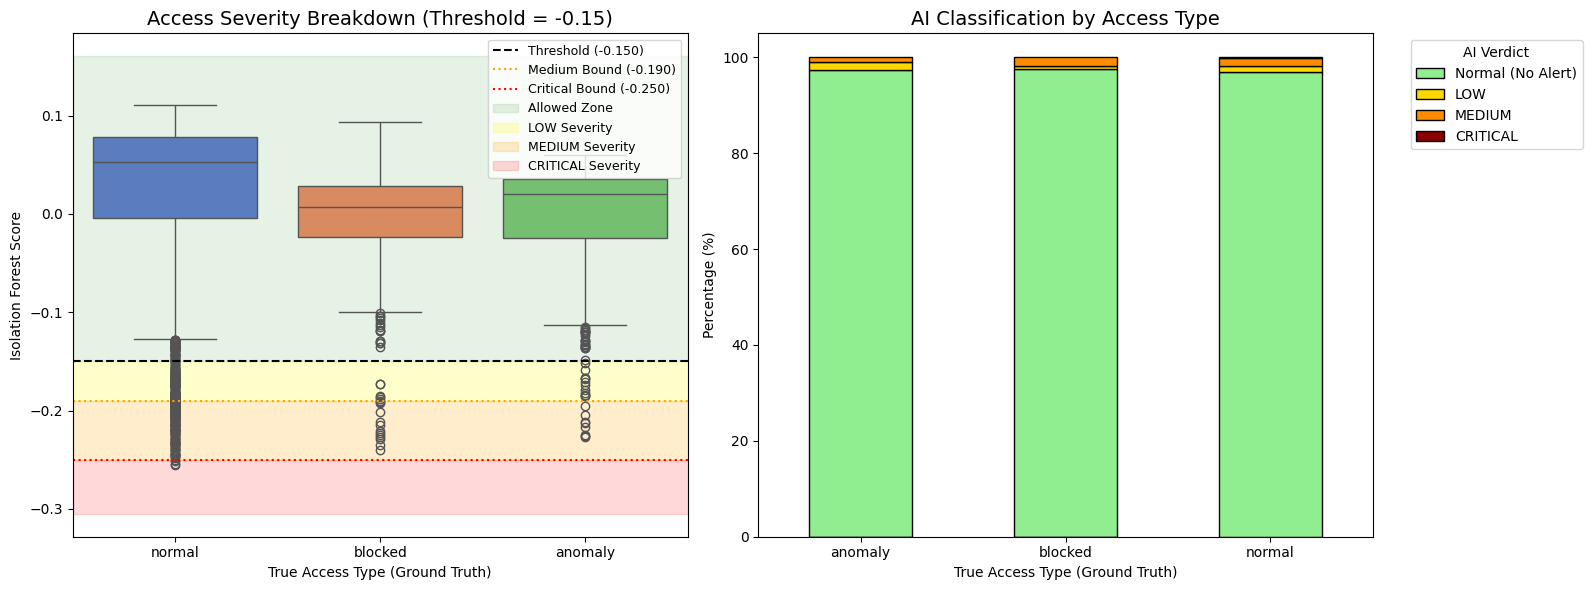

/tmp/ipykernel_1753/3218878555.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ground_truth', y='anomaly_score', data=df, palette='muted')


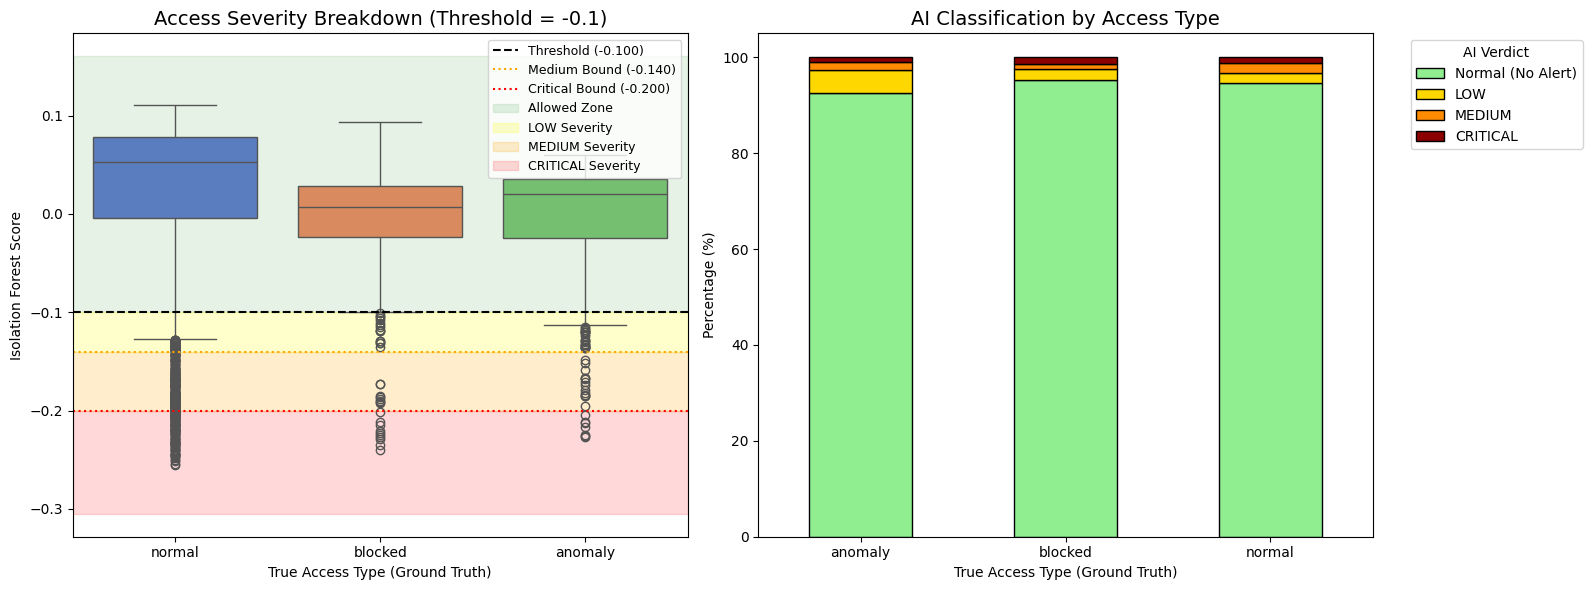

/tmp/ipykernel_1753/3218878555.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ground_truth', y='anomaly_score', data=df, palette='muted')


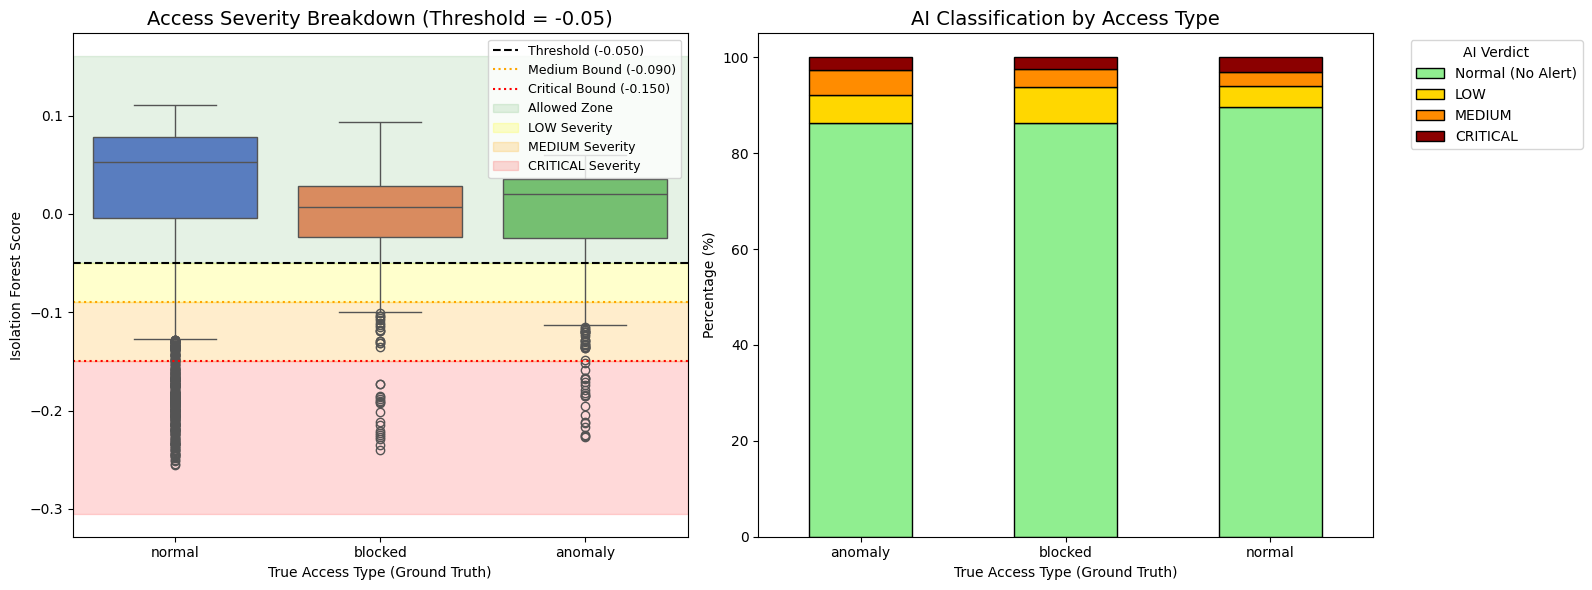

/tmp/ipykernel_1753/3218878555.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ground_truth', y='anomaly_score', data=df, palette='muted')


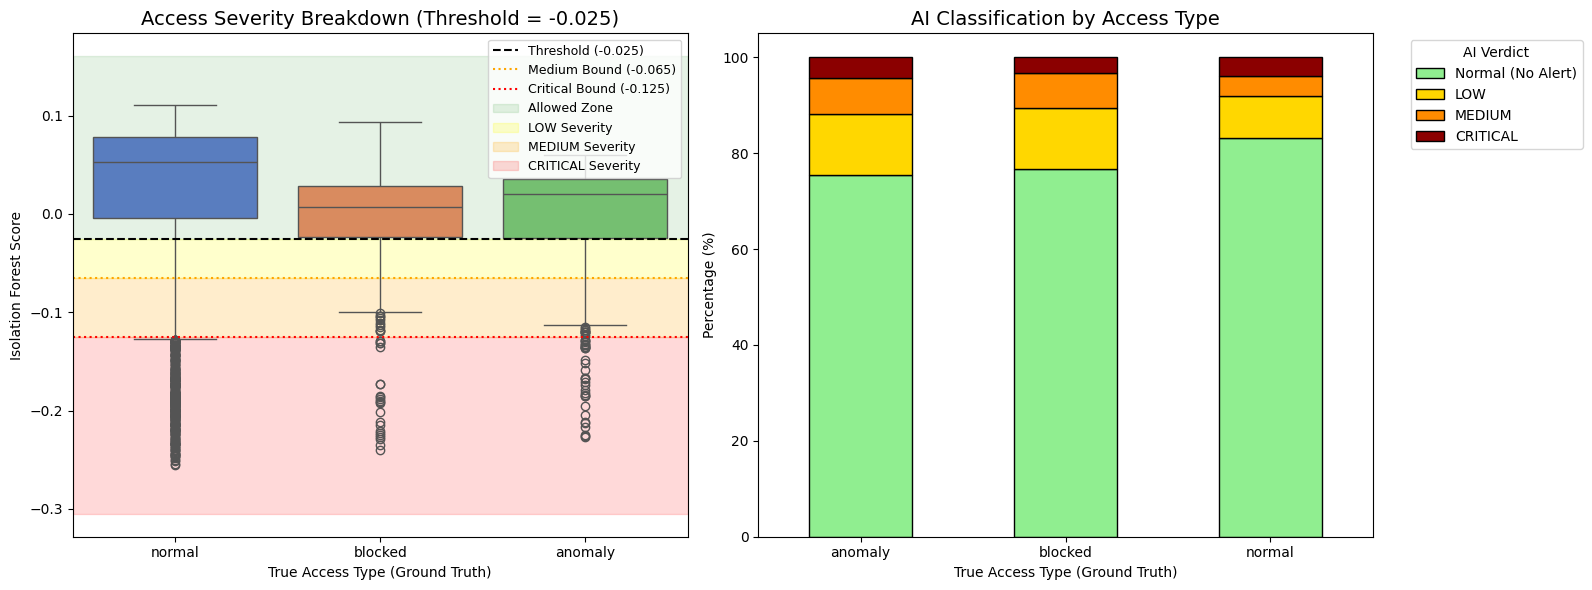

/tmp/ipykernel_1753/3218878555.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ground_truth', y='anomaly_score', data=df, palette='muted')


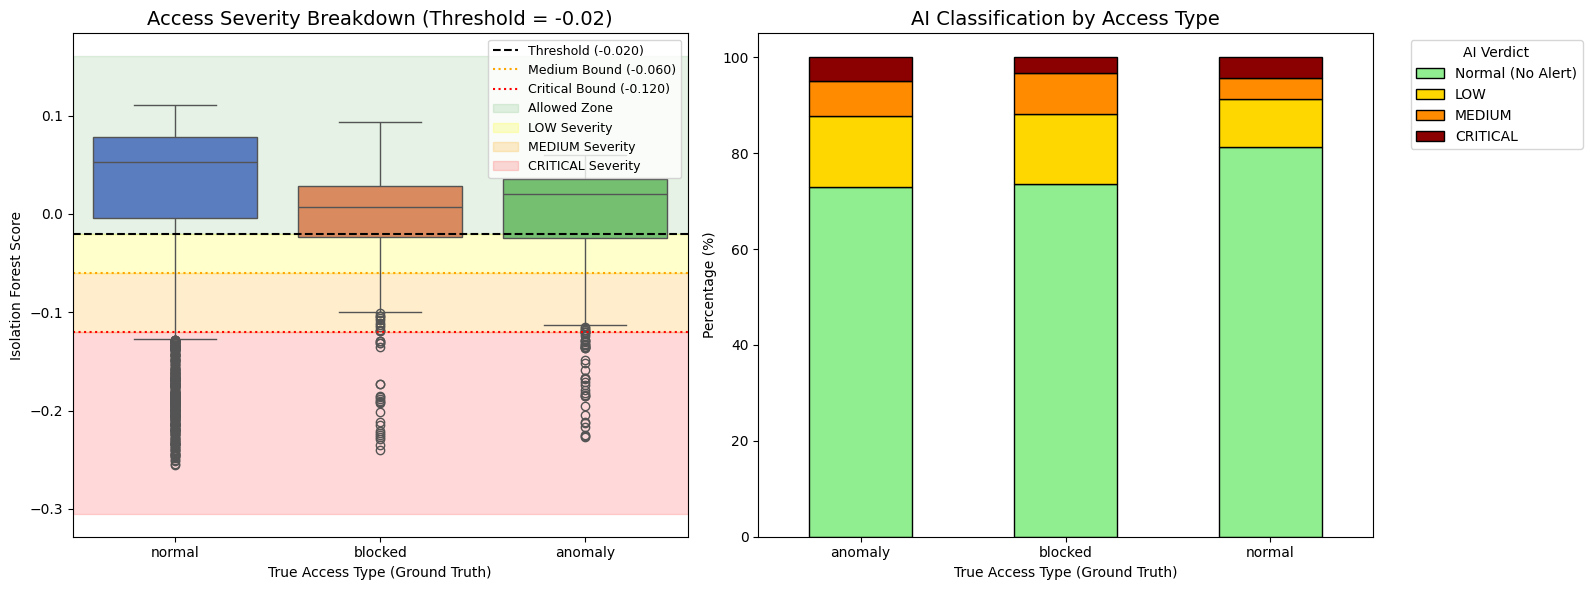

/tmp/ipykernel_1753/3218878555.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ground_truth', y='anomaly_score', data=df, palette='muted')


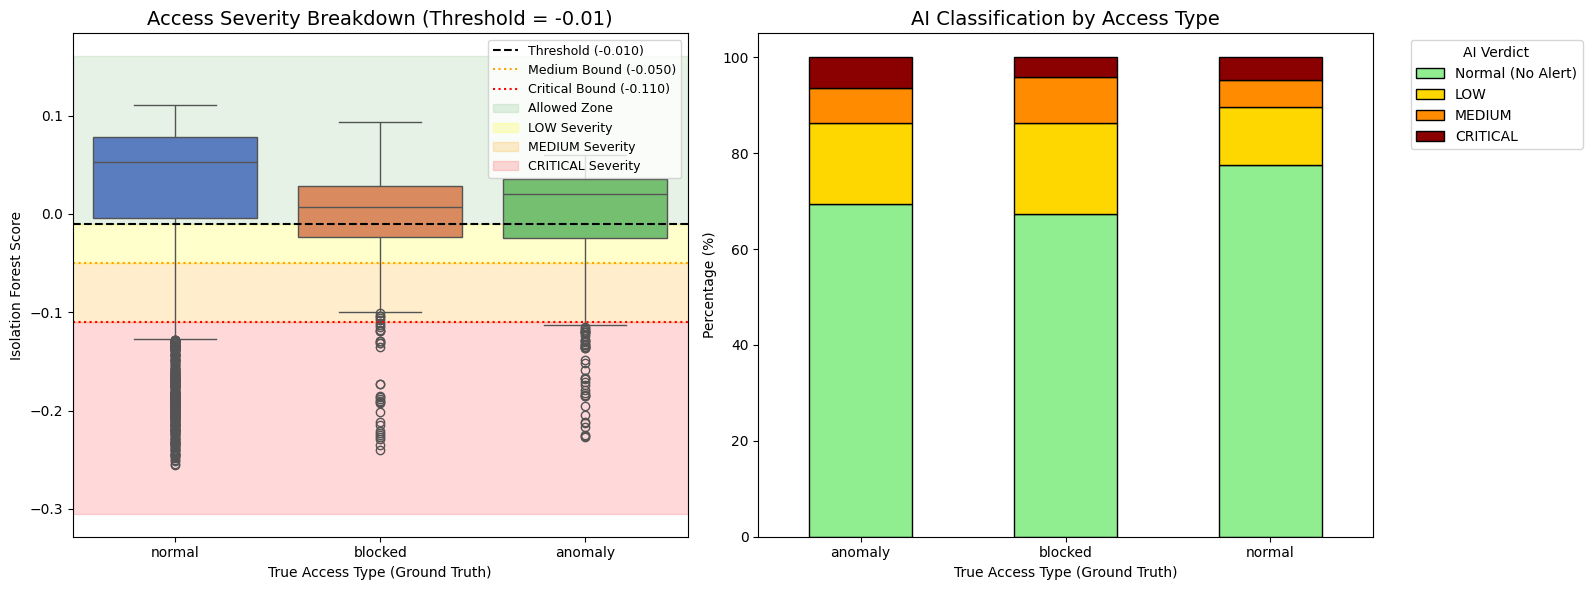

/tmp/ipykernel_1753/3218878555.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ground_truth', y='anomaly_score', data=df, palette='muted')


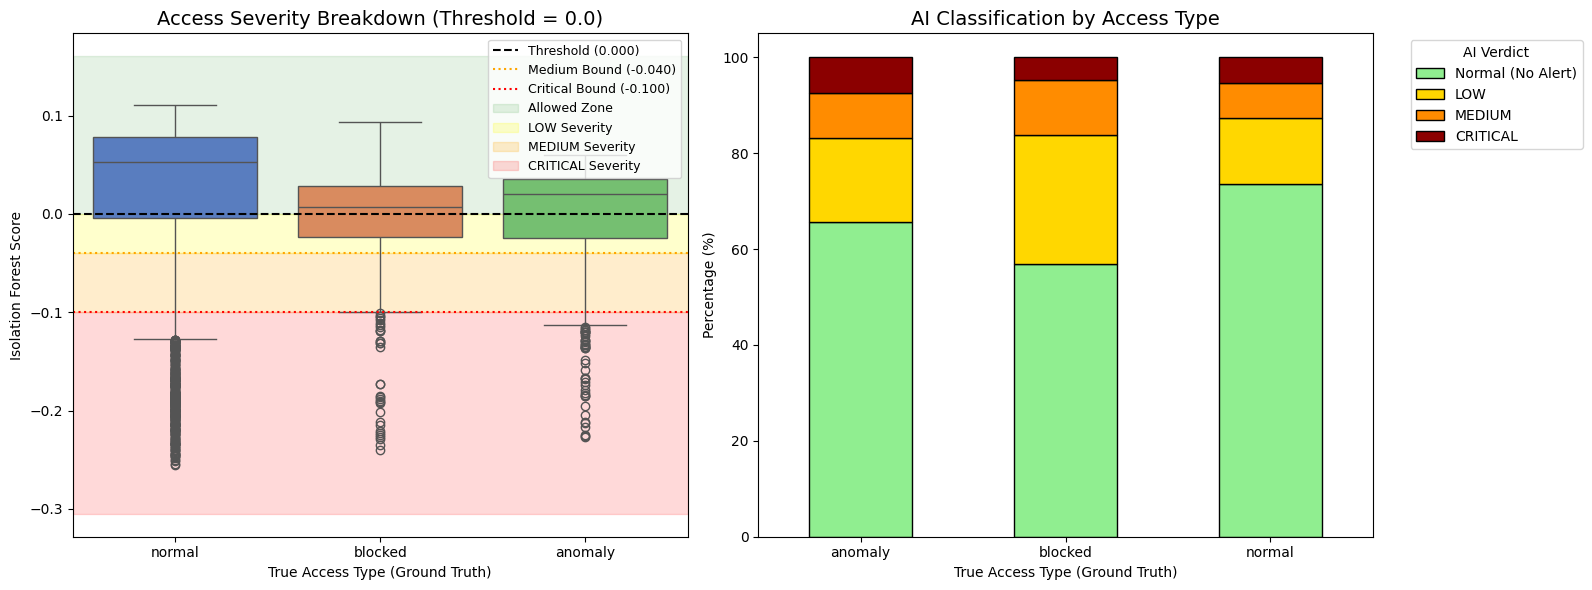

/tmp/ipykernel_1753/3218878555.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ground_truth', y='anomaly_score', data=df, palette='muted')


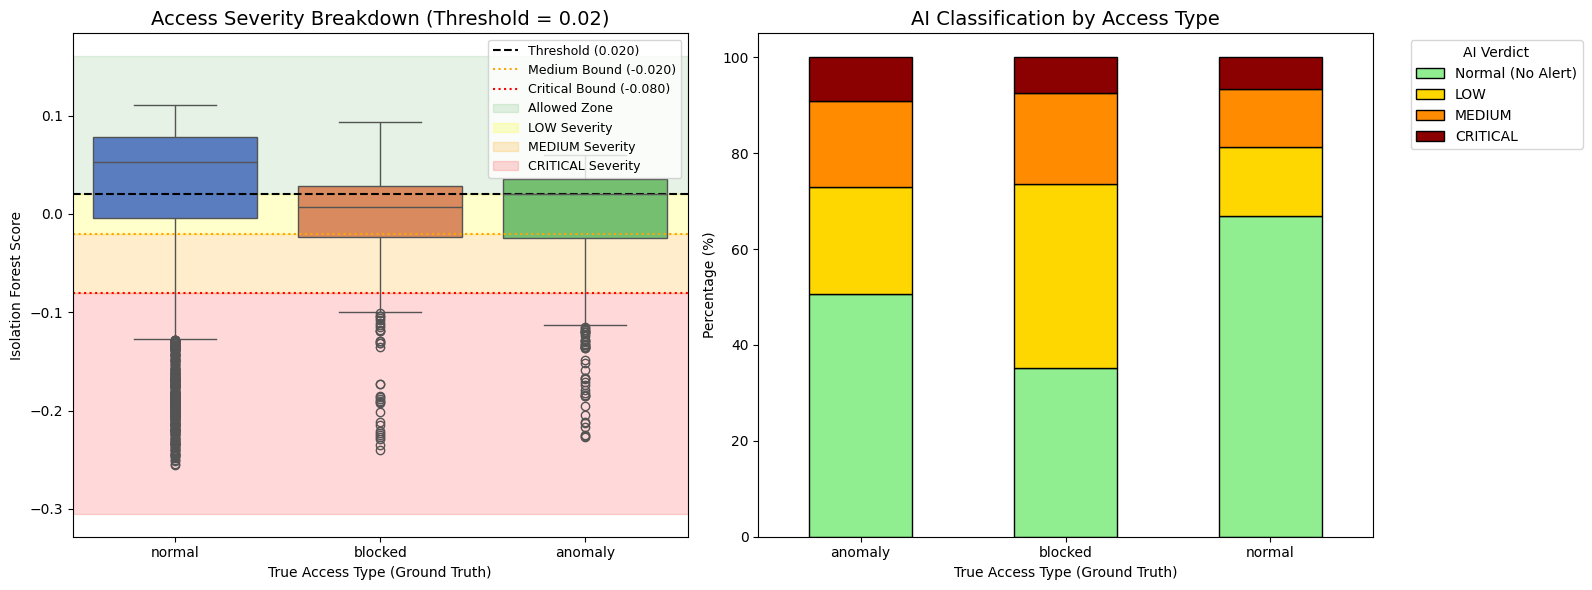

In [5]:
# ==============================================================================
# EXPERIMENT EXECUTION
# ==============================================================================

def run_analysis():
    """
    Main execution pipeline. Prepares data, trains the model, runs predictions
    across multiple operational thresholds, and evaluates performance.
    """
    print("[1/4] Preparing realistic synthetic datasets (Train & Test)...")
    train_df = generate_data(mode='train')
    test_df = generate_data(mode='test')

    # Apply preprocessing components
    for df in [train_df, test_df]:
        df['hour'] = df['access_time'].dt.hour
        df['weekday'] = df['access_time'].dt.dayofweek
        df['is_admin'] = df['role'].apply(lambda x: 1 if x == 'Admin' else 0)

    for col in ['role', 'area']:
        le = LabelEncoder()
        train_df[f'{col}_encoded'] = le.fit_transform(train_df[col])
        label_encoders[col] = le
        test_df[f'{col}_encoded'] = test_df[col].apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else len(le.classes_)
        )

    cols_to_scale = ['hour', 'weekday', 'time_since_last_access', 'access_frequency_1h']
    train_df[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])
    test_df[cols_to_scale] = scaler.transform(test_df[cols_to_scale])

    print("[2/4] Training Unsupervised Isolation Forest model...")
    model.fit(train_df[FEATURE_COLUMNS])

    print("[3/4] Running inference and calculating anomaly scores...")
    scores = model.decision_function(test_df[FEATURE_COLUMNS])

    # Ground truth: 1 for Anomalies/Blocked, 0 for Normal
    y_true = (test_df['ground_truth'] != 'normal').values

    # Test array of potential security thresholds
    thresholds = [-0.15, -0.10, -0.05, -0.025, -0.02, -0.01, 0.0, 0.02]

    print("[4/4] Generating evaluation metrics...")
    results = []
    for t in thresholds:
        y_pred = scores < t
        results.append({
            'Threshold': t,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred),
            'F1-Score': f1_score(y_true, y_pred, zero_division=0),
            'False Positives': confusion_matrix(y_true, y_pred).ravel()[1],
            'Intruder Det.': np.mean([y_pred[i] for i, v in enumerate(test_df['ground_truth'] == 'anomaly') if v]),
            'Blocked Det.': np.mean([y_pred[i] for i, v in enumerate(test_df['ground_truth'] == 'blocked') if v])
        })

    # Display Metrics Table
    results_df = pd.DataFrame(results)
    print("\n=========================================================================")
    print("--- PERFORMANCE SUMMARY TABLE (Isolation Forest Classification) ---")
    print("=========================================================================")
    print(results_df.to_string(index=False))
    print("=========================================================================\n")

    # Generate Visualizations
    plot_advanced_metrics(results_df, scores, y_true)

    # Plot Severity Breakdown for key thresholds
    for t in thresholds:
        plot_severity_analysis(test_df, scores, threshold=t)

# Execute the pipeline
run_analysis()